In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()

Saving processed-data.csv to processed-data.csv


In [3]:
# Load Dataset

df = pd.read_csv("processed-data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


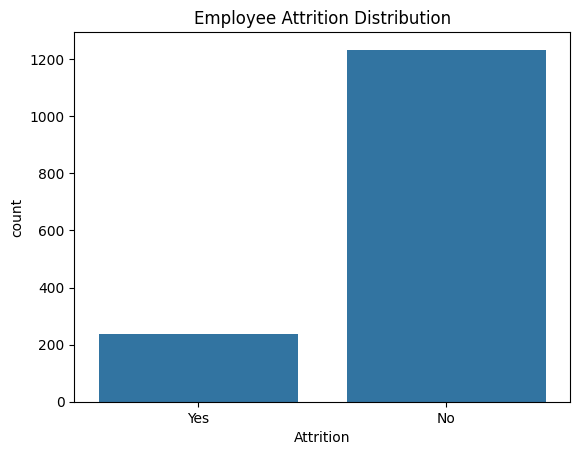

In [4]:
# Attrition Distribution

sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

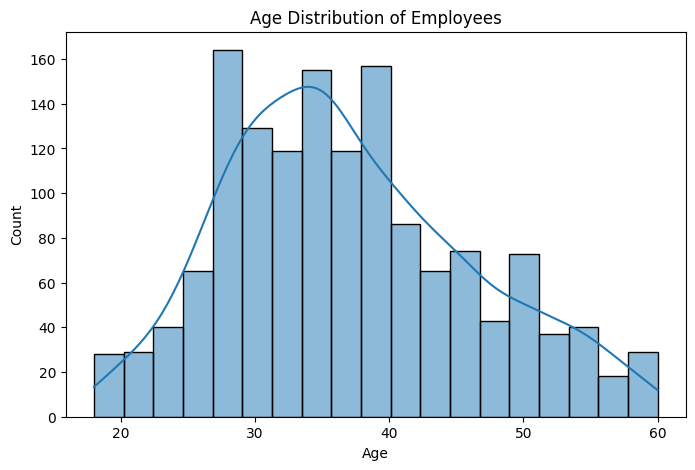

In [5]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Employees")
plt.show()

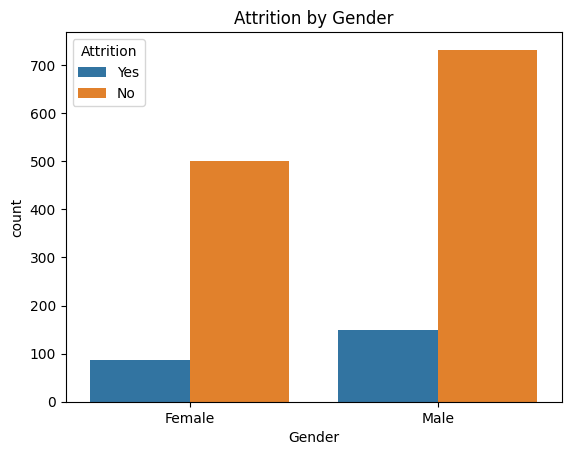

In [6]:
# Attrition vs Gender

sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title("Attrition by Gender")
plt.show()

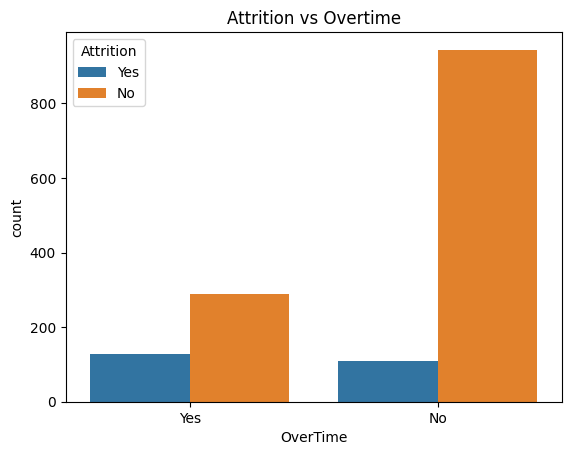

In [7]:
# Attrition vs Overtime

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

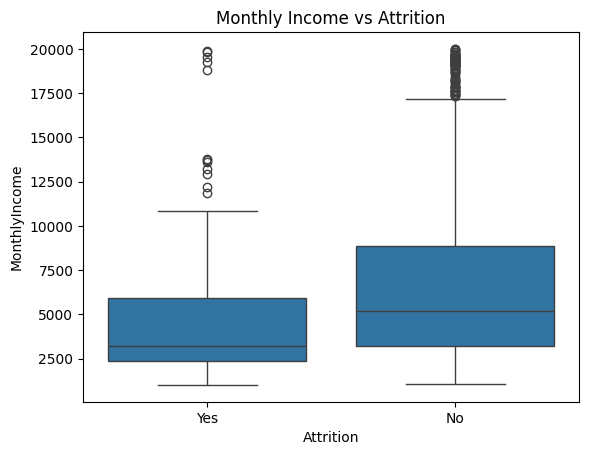

In [8]:
# Salary vs Attrition

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

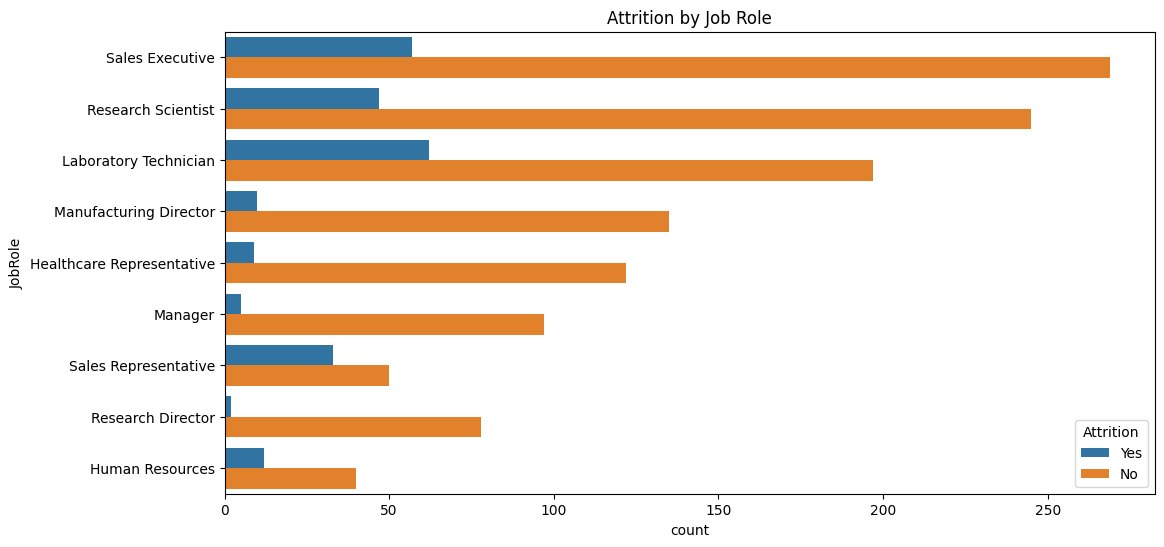

In [9]:
# Job Role vs Attrition

plt.figure(figsize=(12,6))
sns.countplot(y='JobRole', hue='Attrition', data=df)
plt.title("Attrition by Job Role")
plt.show()

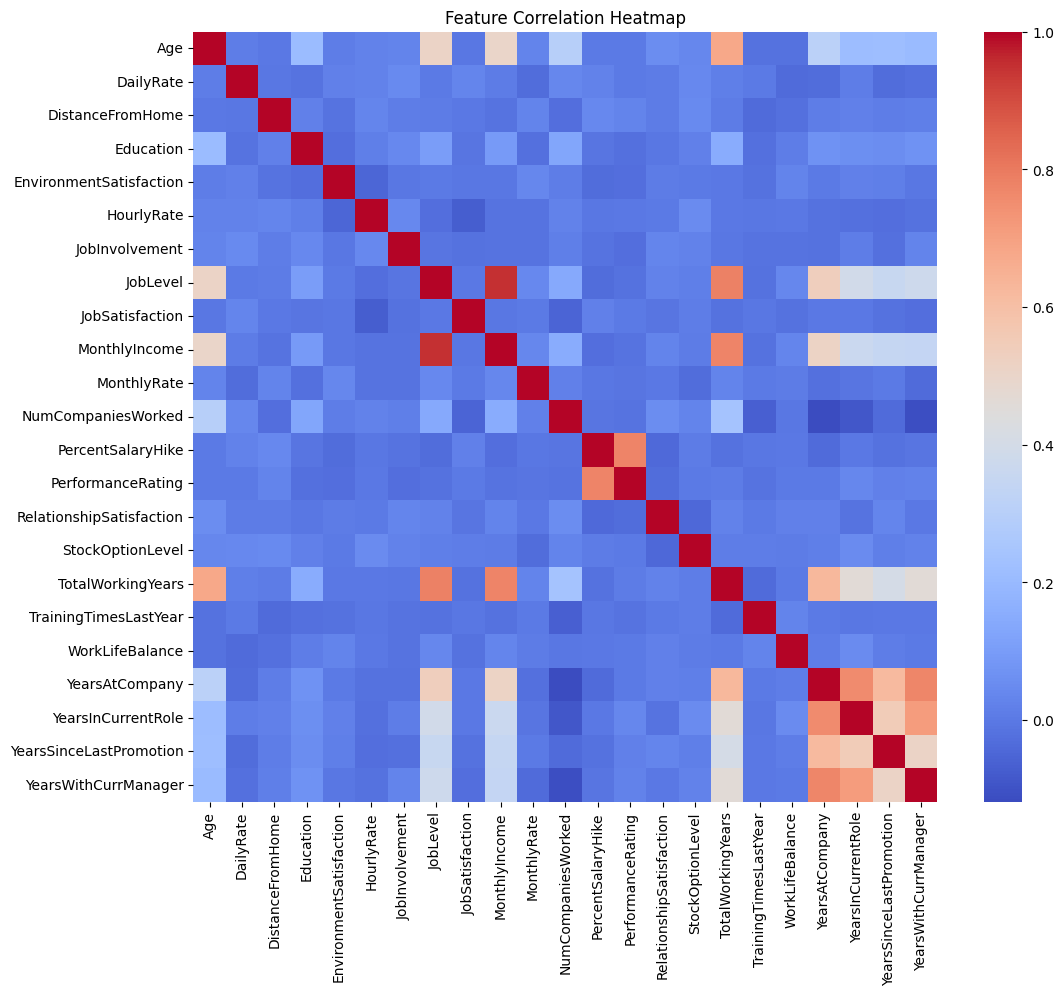

In [10]:
# Correlation Heatmap

plt.figure(figsize=(12,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
# Attrition Rate by Department

dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print("Attrition Rate by Department:\n", dept_attr)

Attrition Rate by Department:
 Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64


In [12]:
# Attrition Rate by Job Role

role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1).sort_values(ascending=False)
print("\nAttrition Rate by Job Role:\n", role_attr)


Attrition Rate by Job Role:
 JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64


In [13]:
# Overtime attrition breakdown

ot = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
print("\nOvertime Attrition %:\n", ot.round(1))


Overtime Attrition %:
 Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5


In [14]:
# Age bracket attrition

df['AgeBracket'] = pd.cut(df['Age'], bins=[18,25,30,35,40,45,50,65],
                           labels=['18-24','25-29','30-34','35-39','40-44','45-49','50+'])
age_attr = df.groupby('AgeBracket', observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print("\nAttrition Rate by Age Bracket:\n", age_attr)


Attrition Rate by Age Bracket:
 AgeBracket
18-24    34.8
25-29    21.3
30-34    17.5
35-39     9.1
40-44     9.4
45-49    12.3
50+      12.6
Name: Attrition, dtype: float64
